In [1]:
# import core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer          
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


In [2]:
!pip install kagglehub[pandas-datasets]

In [3]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/rishantenis/house-prices-advanced-regression/train.csv"
)

print("First 5 records:", df.head())

First 5 records:    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   

In [4]:
import os

print(f"✅ Dataset loaded from: {df}")
print(f"   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Target: SalePrice — min ${df['SalePrice'].min():,}  |  "
      f"max ${df['SalePrice'].max():,}  |  mean ${df['SalePrice'].mean():,.0f}")
df.head(3)

✅ Dataset loaded from:         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


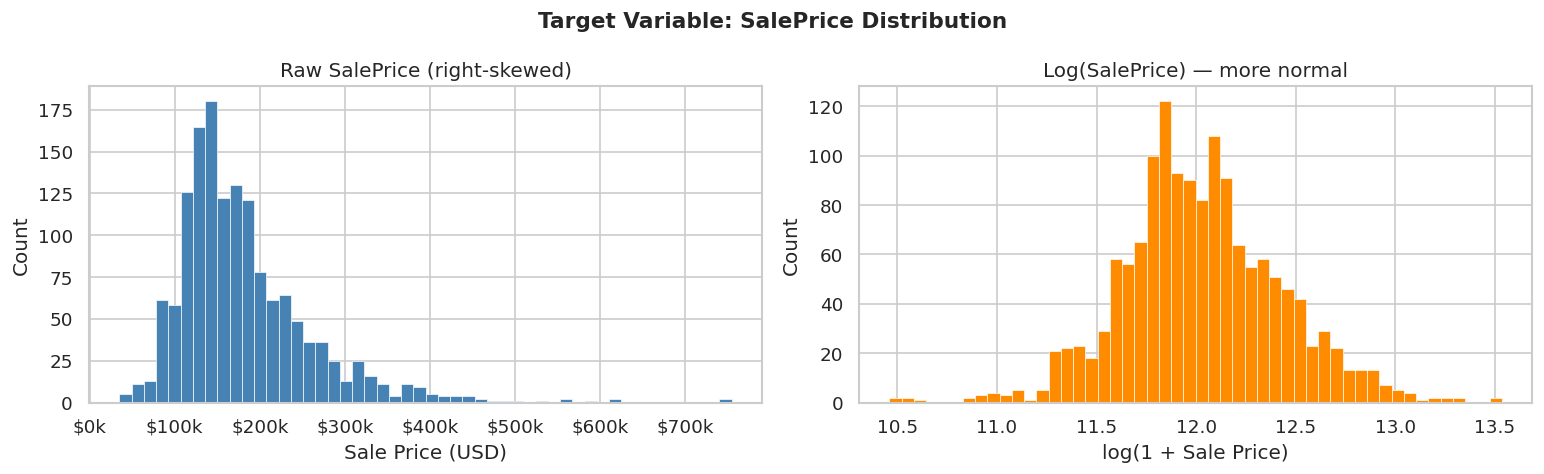

In [5]:
# Target Distribution
# Log-transforming it makes the distribution more normal and improves linear models

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Target Variable: SalePrice Distribution", fontsize=13, fontweight='bold')

# Raw price
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title("Raw SalePrice (right-skewed)")
axes[0].set_xlabel("Sale Price (USD)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

# Log-transformed price
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='darkorange', edgecolor='white', linewidth=0.4)
axes[1].set_title("Log(SalePrice) — more normal")
axes[1].set_xlabel("log(1 + Sale Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

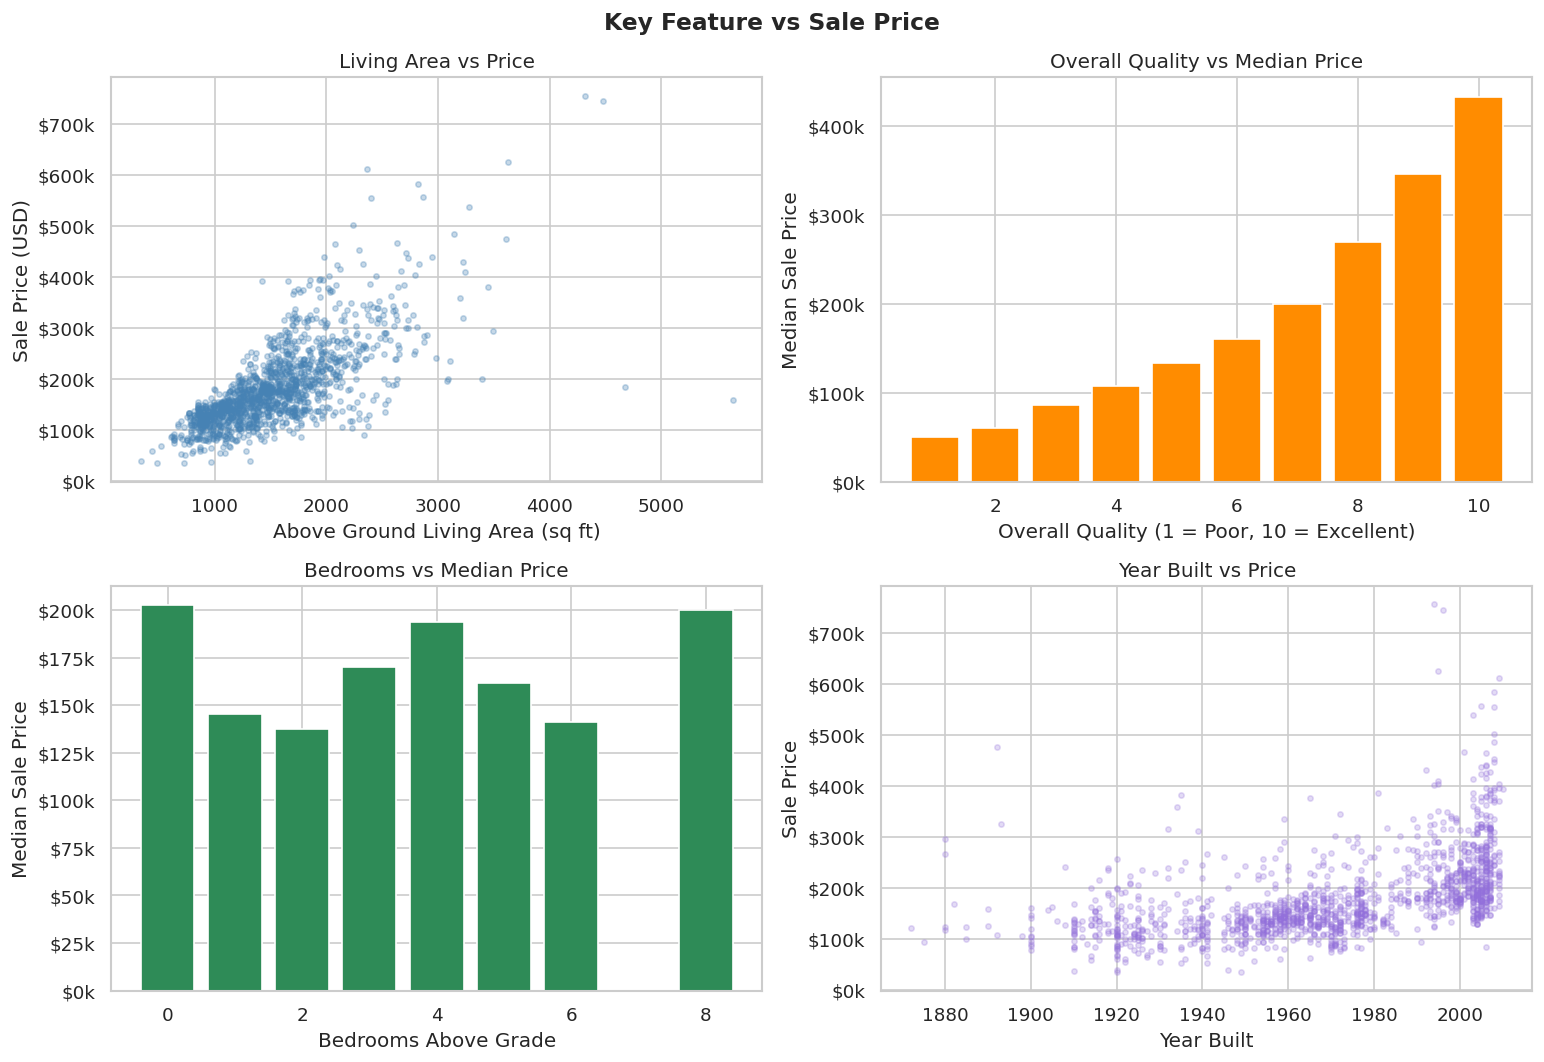

In [6]:
# Key Feature Relationships 

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Key Feature vs Sale Price", fontsize=14, fontweight='bold')

# 1. Above-ground living area (square footage)
axes[0,0].scatter(df['GrLivArea'], df['SalePrice'],
                  alpha=0.3, s=10, color='steelblue')
axes[0,0].set_xlabel("Above Ground Living Area (sq ft)")
axes[0,0].set_ylabel("Sale Price (USD)")
axes[0,0].set_title("Living Area vs Price")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

# 2. Overall quality rating (1-10)
quality_means = df.groupby('OverallQual')['SalePrice'].median().reset_index()
axes[0,1].bar(quality_means['OverallQual'], quality_means['SalePrice'],
              color='darkorange', edgecolor='white')
axes[0,1].set_xlabel("Overall Quality (1 = Poor, 10 = Excellent)")
axes[0,1].set_ylabel("Median Sale Price")
axes[0,1].set_title("Overall Quality vs Median Price")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

# 3. Number of bedrooms above grade
bedroom_means = df.groupby('BedroomAbvGr')['SalePrice'].median().reset_index()
axes[1,0].bar(bedroom_means['BedroomAbvGr'], bedroom_means['SalePrice'],
              color='seagreen', edgecolor='white')
axes[1,0].set_xlabel("Bedrooms Above Grade")
axes[1,0].set_ylabel("Median Sale Price")
axes[1,0].set_title("Bedrooms vs Median Price")
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

# 4. Year built vs price
axes[1,1].scatter(df['YearBuilt'], df['SalePrice'],
                  alpha=0.25, s=10, color='mediumpurple')
axes[1,1].set_xlabel("Year Built")
axes[1,1].set_ylabel("Sale Price")
axes[1,1].set_title("Year Built vs Price")
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

These 4 plots show the most intuitive drivers of house price

 19 columns have missing values:

              Missing Count  Missing %
PoolQC                 1453       99.5
MiscFeature            1406       96.3
Alley                  1369       93.8
Fence                  1179       80.8
MasVnrType              872       59.7
FireplaceQu             690       47.3
LotFrontage             259       17.7
GarageType               81        5.5
GarageYrBlt              81        5.5
GarageFinish             81        5.5
GarageQual               81        5.5
GarageCond               81        5.5
BsmtExposure             38        2.6
BsmtFinType2             38        2.6
BsmtQual                 37        2.5
BsmtCond                 37        2.5
BsmtFinType1             37        2.5
MasVnrArea                8        0.5
Electrical                1        0.1


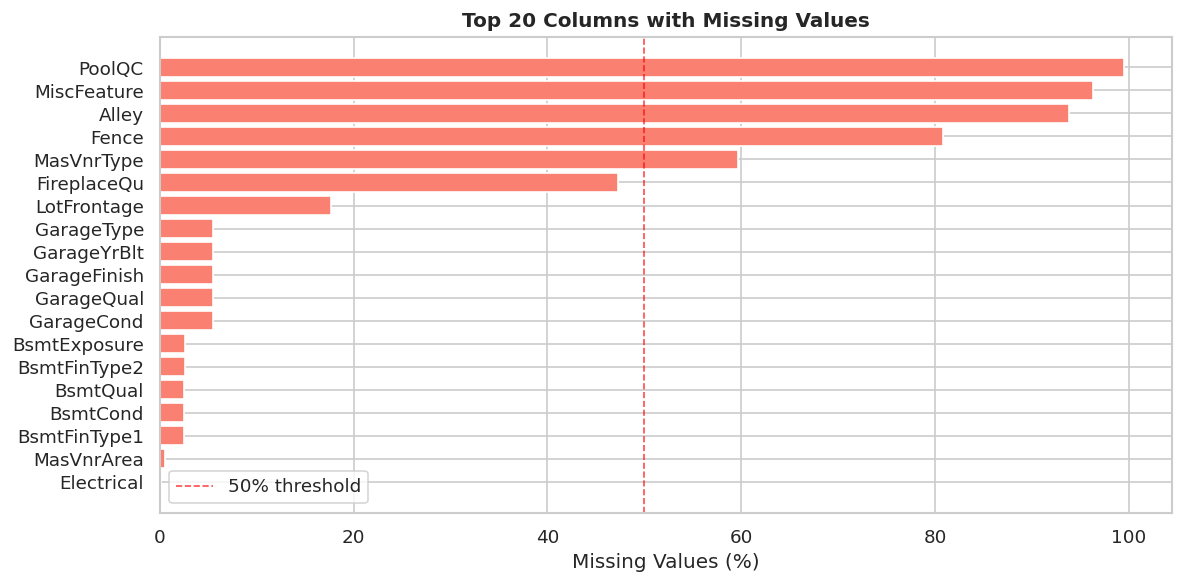

In [7]:
# Missing Value Analysis to identify columns with significant missing data before we decide how to handle them

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

print(f" {len(missing)} columns have missing values:\n")
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df.head(20).to_string())

# Visualize the top 20 most-missing columns
fig, ax = plt.subplots(figsize=(10, 5))
top20 = missing_pct.head(20)
bars = ax.barh(top20.index[::-1], top20.values[::-1], color='salmon', edgecolor='white')
ax.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='50% threshold')
ax.set_xlabel("Missing Values (%)")
ax.set_title("Top 20 Columns with Missing Values", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Data Preprocessing: By dropping high-missing columns
# Columns with >45% missing are unreliable; drop them
HIGH_MISS_THRESHOLD = 45

cols_to_drop = missing_pct[missing_pct > HIGH_MISS_THRESHOLD].index.tolist()
print(f"🗑️  Dropping {len(cols_to_drop)} columns with >{HIGH_MISS_THRESHOLD}% missing:")
print("  ", cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)

# Also drop 'Id' — it's just a row identifier, not a feature
df.drop(columns=['Id'], inplace=True, errors='ignore')

print(f"\n✅ Shape after dropping: {df.shape}")

🗑️  Dropping 6 columns with >45% missing:
   ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']

✅ Shape after dropping: (1460, 74)


In [9]:
# Separate Numerical and Categorical Columns: median imputation for numbers, mode for categories

# Separate target from features
y_raw = df['SalePrice'].copy()
X_raw = df.drop(columns=['SalePrice'])

# Identify column types
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_raw.select_dtypes(include=['object']).columns.tolist()

print(f" Numerical columns : {len(num_cols)}")
print(f" Categorical columns: {len(cat_cols)}")
print(f"\n   Sample categorical: {cat_cols[:8]}")

 Numerical columns : 36
 Categorical columns: 37

   Sample categorical: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood']


In [10]:
# Impute Missing Values
# Numerical  -> fill with median (robust to outliers)
# Categorical -> fill with most frequent value (mode)

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_num = pd.DataFrame(
    num_imputer.fit_transform(X_raw[num_cols]),
    columns=num_cols
)

X_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_raw[cat_cols]),
    columns=cat_cols
)

print(f" Imputation complete.")
print(f"   Numerical missing after imputation : {X_num.isnull().sum().sum()}")
print(f"   Categorical missing after imputation: {X_cat.isnull().sum().sum()}")

 Imputation complete.
   Numerical missing after imputation : 0
   Categorical missing after imputation: 0


In [11]:
# Encode Categorical Columns
# LabelEncoder converts string categories into integers
# e.g., 'Excellent' -> 0, 'Good' -> 1, 'Poor' -> 2 (order is alphabetical, not ordinal)
# For a more refined approach, one-hot encoding could be used instead

le = LabelEncoder()
X_cat_encoded = X_cat.copy()

for col in cat_cols:
    X_cat_encoded[col] = le.fit_transform(X_cat_encoded[col].astype(str))

# Combine numerical and encoded categorical features 
X_combined = pd.concat([X_num, X_cat_encoded], axis=1)

print(f" Encoding complete. Final feature matrix shape: {X_combined.shape}")

 Encoding complete. Final feature matrix shape: (1460, 73)


In [12]:
# Feature Engineering: Create a few new features that capture domain knowledge about real estate

# Total area including basement (more comprehensive size measure)
X_combined['TotalSF'] = X_num['GrLivArea'] + X_num.get('TotalBsmtSF', 0)

# Total bathrooms (full + half, upstairs + basement)
X_combined['TotalBaths'] = (
    X_num.get('FullBath', 0)
    + 0.5 * X_num.get('HalfBath', 0)
    + X_num.get('BsmtFullBath', 0)
    + 0.5 * X_num.get('BsmtHalfBath', 0)
)

# Age of house at time of sale
X_combined['HouseAge'] = X_num['YrSold'] - X_num['YearBuilt']

# Was the house remodelled? (1 = yes, 0 = no)
X_combined['Remodelled'] = (X_num['YearRemodAdd'] != X_num['YearBuilt']).astype(int)

# Total porch area
porch_cols = ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
available_porch = [c for c in porch_cols if c in X_num.columns]
X_combined['TotalPorchSF'] = X_num[available_porch].sum(axis=1)

print(f" Feature engineering complete. New shape: {X_combined.shape}")
print("   New features: TotalSF, TotalBaths, HouseAge, Remodelled, TotalPorchSF")

 Feature engineering complete. New shape: (1460, 78)
   New features: TotalSF, TotalBaths, HouseAge, Remodelled, TotalPorchSF


## 🎯 Step 5: Feature Selection

With 70+ features, we use `SelectKBest` with F-statistic to keep only the most statistically relevant ones.

In [13]:
# Log-transform the target 
# log1p(x) = log(1+x): transforms right-skewed price distribution to normal
# This makes linear models work much better
# We'll reverse this with np.expm1() when showing final predictions
y = np.log1p(y_raw)

# Select Top K Features i.e. 40 most correlated features with SalePrice
K = 40   

selector = SelectKBest(score_func=f_regression, k=K)
X_selected = selector.fit_transform(X_combined.fillna(0), y)

# Get the names of selected features
selected_mask  = selector.get_support()
selected_feats = X_combined.columns[selected_mask].tolist()

print(f" Selected top {K} features out of {X_combined.shape[1]} total")
print("\n Selected features:")
print(", ".join(selected_feats))

 Selected top 40 features out of 78 total

 Selected features:
LotFrontage, LotArea, OverallQual, YearBuilt, YearRemodAdd, MasVnrArea, BsmtFinSF1, BsmtUnfSF, TotalBsmtSF, 1stFlrSF, 2ndFlrSF, GrLivArea, BsmtFullBath, FullBath, HalfBath, BedroomAbvGr, TotRmsAbvGrd, Fireplaces, GarageYrBlt, GarageCars, GarageArea, WoodDeckSF, OpenPorchSF, LotShape, HouseStyle, ExterQual, Foundation, BsmtQual, BsmtExposure, HeatingQC, CentralAir, Electrical, KitchenQual, GarageType, GarageFinish, PavedDrive, SaleCondition, TotalSF, TotalBaths, HouseAge


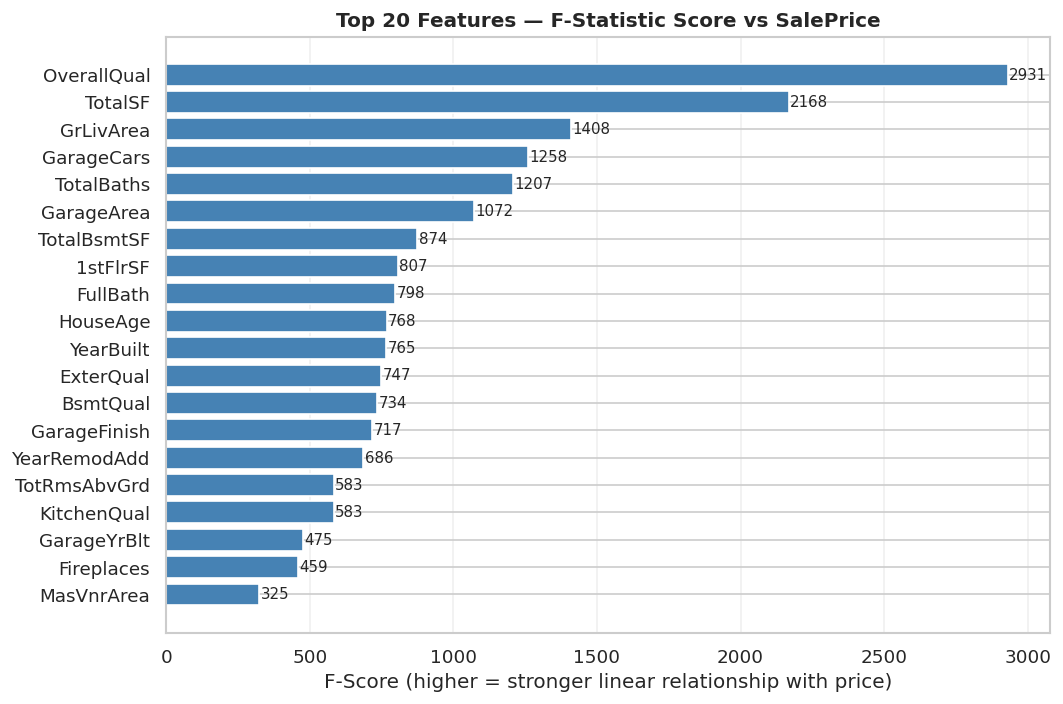

In [14]:
# Visualise Top 20 Feature Importance Scores
scores = pd.Series(selector.scores_[selected_mask], index=selected_feats)
scores_top20 = scores.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(scores_top20.index, scores_top20.values,
               color='steelblue', edgecolor='white')

for bar, val in zip(bars, scores_top20.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9)

ax.set_title("Top 20 Features — F-Statistic Score vs SalePrice",
             fontsize=12, fontweight='bold')
ax.set_xlabel("F-Score (higher = stronger linear relationship with price)")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
X_final = X_combined[selected_feats].fillna(0).values
# log-transformed SalePrice
y_final = y.values   

#  Train / Test Split & Feature Scaling: 80/20 Split
# random_state=42 ensures reproducibility
# shuffle=True is fine here — unlike time series, house sales have no order dependency
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.20, random_state=42
)

print(f" Training samples : {len(X_train):,}")
print(f" Test samples     : {len(X_test):,}")

# Feature Scaling using StandardScaler: (x - mean) / std -> zero mean, unit variance
# Critical for Linear Regression (gradient-based)
# Less critical for Gradient Boosting, but doesn't hurt
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only → prevents leakage
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print("\n Split and scaling complete.")

 Training samples : 1,168
 Test samples     : 292

 Split and scaling complete.


In [16]:
# Model 1: Ridge Regression 
# Ridge adds a penalty term (alpha * sum of squared coefficients) to the loss
# This shrinks large coefficients and reduces overfitting vs plain LinearRegression
ridge = Ridge(alpha=10.0)   # alpha controls regularization strength
ridge.fit(X_train_sc, y_train)
ridge_preds_log = ridge.predict(X_test_sc)

print(" Ridge Regression trained.")

# Model 2: Gradient Boosting Regressor
# Hyperparameters:
#   n_estimators  = number of boosting rounds (more = better but slower)
#   learning_rate = how much each tree corrects previous errors (smaller = more robust)
#   max_depth     = complexity of each individual tree
#   subsample     = fraction of training data for each tree (prevents overfitting)
gb = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)
gb.fit(X_train_sc, y_train)
gb_preds_log = gb.predict(X_test_sc)

print(" Gradient Boosting trained.")

 Ridge Regression trained.
 Gradient Boosting trained.


In [17]:
# Reverse the log-transform for interpretable USD predictions
# np.expm1(x) = e^x - 1 (inverse of np.log1p)
# This converts log-scale predictions back to actual dollar amounts

ridge_preds = np.expm1(ridge_preds_log)   # → USD
gb_preds    = np.expm1(gb_preds_log)      # → USD
y_test_usd  = np.expm1(y_test)            # Actual prices in USD

print(f" Sample actual prices   : {y_test_usd[:5].astype(int).tolist()}")
print(f" Sample Ridge preds     : {ridge_preds[:5].astype(int).tolist()}")
print(f" Sample GB preds        : {gb_preds[:5].astype(int).tolist()}")

 Sample actual prices   : [154500, 324999, 114999, 158999, 315500]
 Sample Ridge preds     : [138606, 323428, 118367, 161002, 328915]
 Sample GB preds        : [144729, 326781, 111900, 143450, 317848]


In [18]:
# Evaluation
def evaluate_model(name, y_true, y_pred):
    """
    Compute and print regression evaluation metrics.

    MAE  (Mean Absolute Error)      — average dollar prediction error
    RMSE (Root Mean Squared Error)  — penalises large errors more
    R²   (Coefficient of Determination) — % of variance explained (1.0 = perfect)
    MAPE (Mean Absolute % Error)    — relative error as percentage
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{'─'*44}")
    print(f"  {name}")
    print(f"{'─'*44}")
    print(f"  MAE  : ${mae:>10,.0f}  (avg absolute error)")
    print(f"  RMSE : ${rmse:>10,.0f}  (penalises large errors)")
    print(f"  R²   : {r2:>13.4f}  (1.0 = perfect)")
    print(f"  MAPE : {mape:>12.2f}%  (relative % error)")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Cross-validation scores on training set (5-fold)
# Negative because sklearn minimizes loss; we negate back to positive MAE
ridge_cv = -cross_val_score(ridge, X_train_sc, y_train,
                             cv=5, scoring='neg_mean_absolute_error')
gb_cv    = -cross_val_score(gb, X_train_sc, y_train,
                             cv=5, scoring='neg_mean_absolute_error')

print(f"\n 5-Fold CV MAE on LOG scale:")
print(f"   Ridge    : {ridge_cv.mean():.4f} ± {ridge_cv.std():.4f}")
print(f"   Gradient Boosting: {gb_cv.mean():.4f} ± {gb_cv.std():.4f}")

print("\n Test Set Performance (USD scale):")
ridge_metrics = evaluate_model("Ridge Regression",      y_test_usd, ridge_preds)
gb_metrics    = evaluate_model("Gradient Boosting",     y_test_usd, gb_preds)


 5-Fold CV MAE on LOG scale:
   Ridge    : 0.1041 ± 0.0071
   Gradient Boosting: 0.0931 ± 0.0061

 Test Set Performance (USD scale):

────────────────────────────────────────────
  Ridge Regression
────────────────────────────────────────────
  MAE  : $    19,419  (avg absolute error)
  RMSE : $    29,360  (penalises large errors)
  R²   :        0.8876  (1.0 = perfect)
  MAPE :        11.64%  (relative % error)

────────────────────────────────────────────
  Gradient Boosting
────────────────────────────────────────────
  MAE  : $    17,610  (avg absolute error)
  RMSE : $    30,804  (penalises large errors)
  R²   :        0.8763  (1.0 = perfect)
  MAPE :        10.42%  (relative % error)


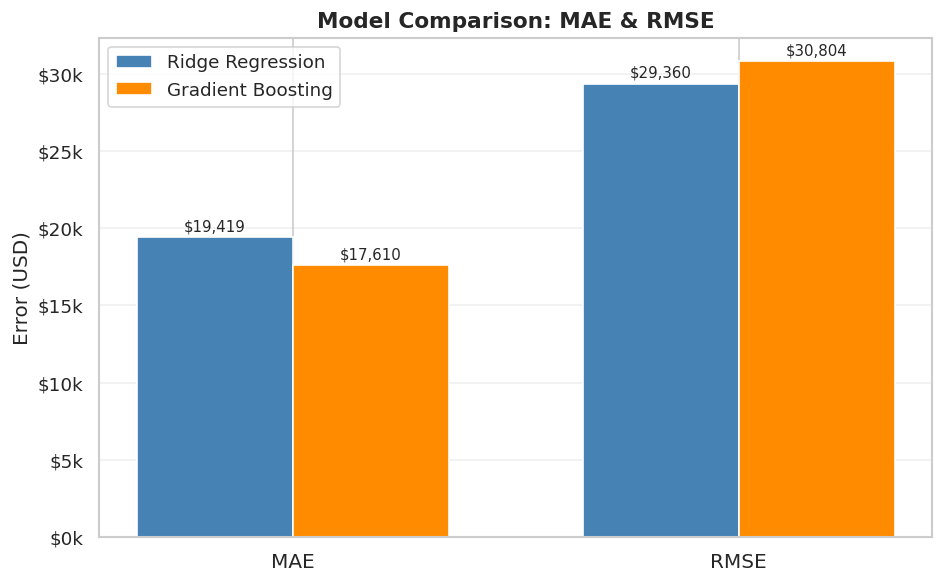

In [19]:
# Side-by-Side Metrics Bar Chart
metric_names = ['MAE', 'RMSE']
ridge_vals = [ridge_metrics['MAE'], ridge_metrics['RMSE']]
gb_vals    = [gb_metrics['MAE'],    gb_metrics['RMSE']]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, ridge_vals, width, label='Ridge Regression',
             color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, gb_vals,    width, label='Gradient Boosting',
             color='darkorange', edgecolor='white')

# Annotate bars
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel("Error (USD)")
ax.set_title("Model Comparison: MAE & RMSE", fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

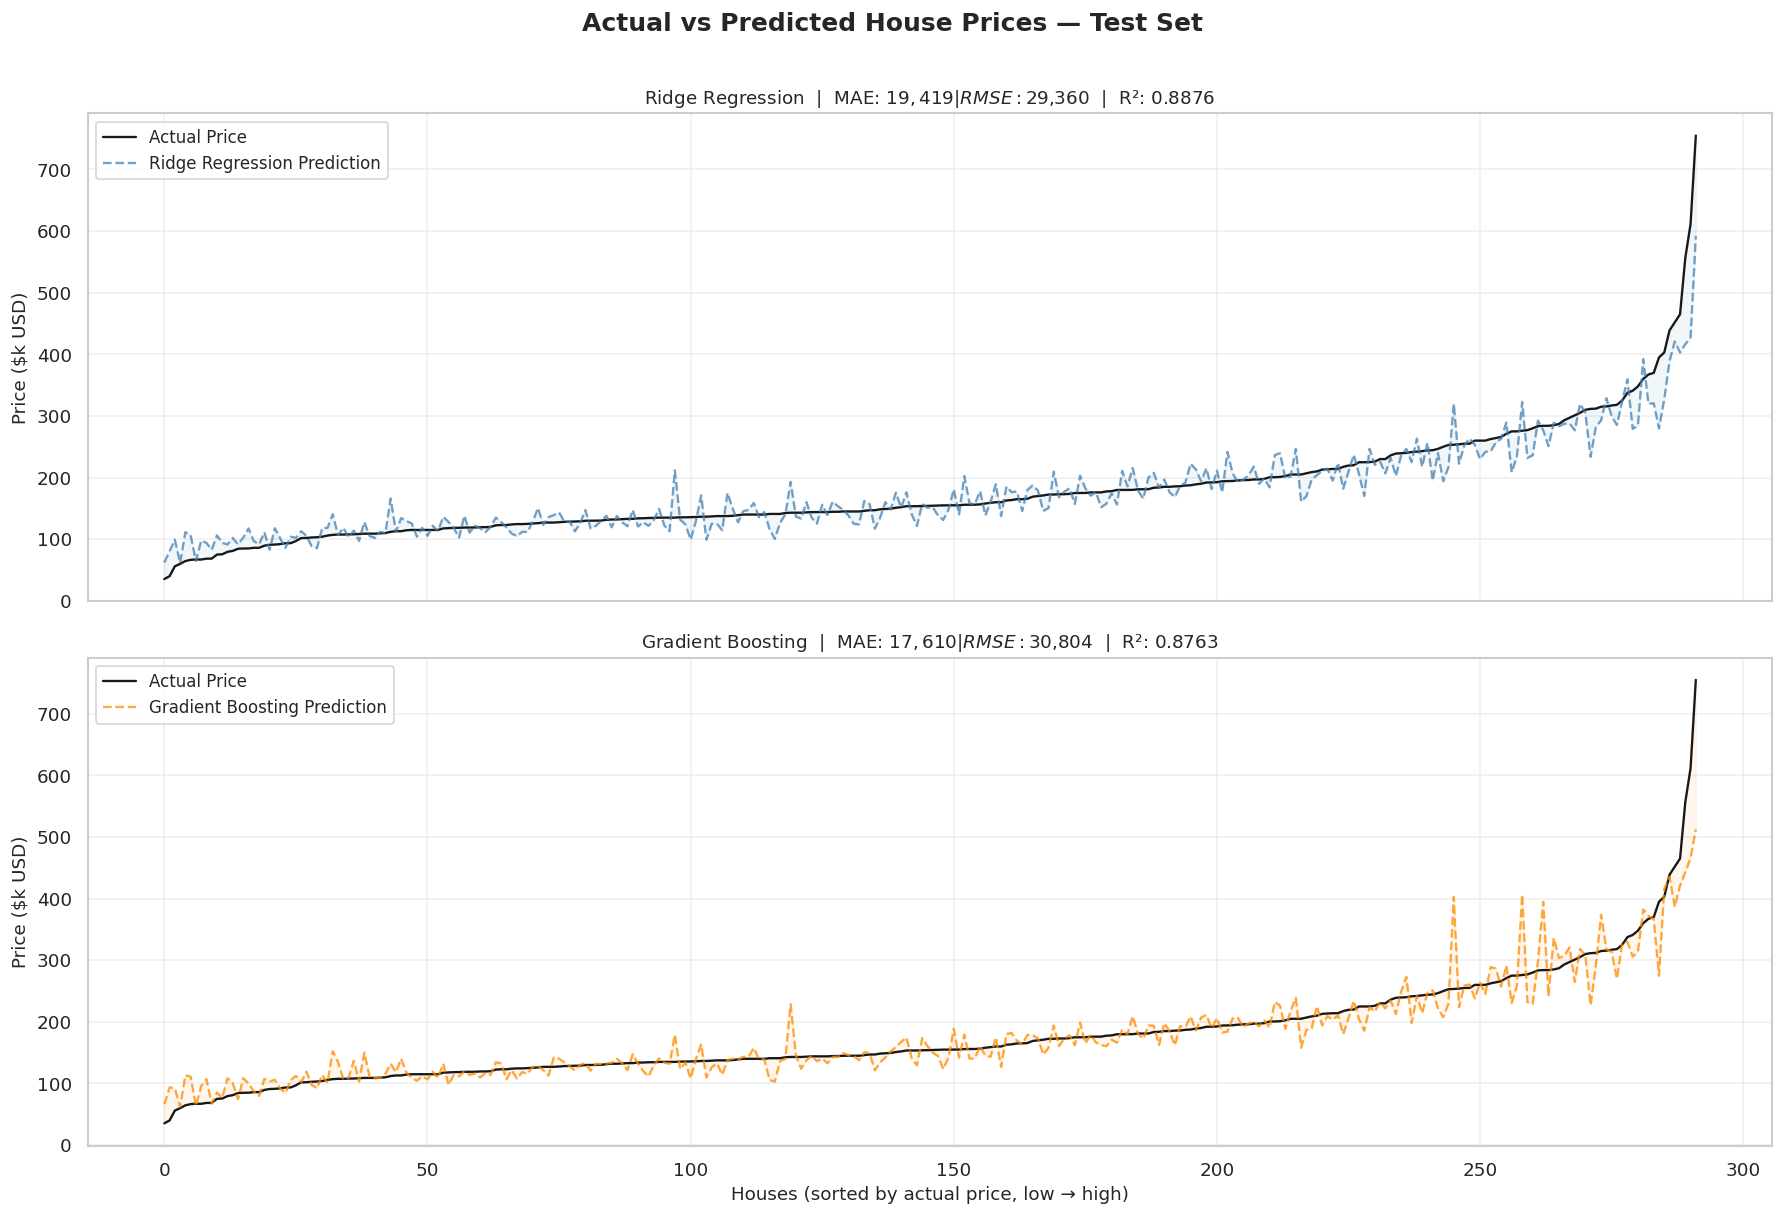

 Plot saved as 'actual_vs_predicted_house.png'


In [20]:
# Sort by actual price for a cleaner line chart
sort_idx = np.argsort(y_test_usd)
actual_sorted = y_test_usd[sort_idx]
ridge_sorted  = ridge_preds[sort_idx]
gb_sorted     = gb_preds[sort_idx]

# Line Plot: Visualize Actual vs Predicted Prices
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle("Actual vs Predicted House Prices — Test Set",
             fontsize=15, fontweight='bold', y=1.01)

sample_idx = np.arange(len(actual_sorted))   # x-axis: house index

for ax, preds, title, color, metrics in zip(
    axes,
    [ridge_sorted, gb_sorted],
    ['Ridge Regression', 'Gradient Boosting'],
    ['steelblue', 'darkorange'],
    [ridge_metrics, gb_metrics]
):
    ax.plot(sample_idx, actual_sorted / 1e3, color='black',
            linewidth=1.4, label='Actual Price', alpha=0.9)
    ax.plot(sample_idx, preds / 1e3, color=color,
            linewidth=1.4, label=f'{title} Prediction',
            alpha=0.75, linestyle='--')

    # Shade the gap between actual and predicted
    ax.fill_between(sample_idx, actual_sorted / 1e3, preds / 1e3,
                    alpha=0.07, color=color)

    ax.set_ylabel("Price ($k USD)", fontsize=11)
    ax.set_title(
        f"{title}  |  MAE: ${metrics['MAE']:,.0f}  |  "
        f"RMSE: ${metrics['RMSE']:,.0f}  |  R²: {metrics['R2']:.4f}",
        fontsize=11
    )
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

axes[1].set_xlabel("Houses (sorted by actual price, low → high)", fontsize=11)
plt.tight_layout()
plt.savefig('actual_vs_predicted_house.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved as 'actual_vs_predicted_house.png'")

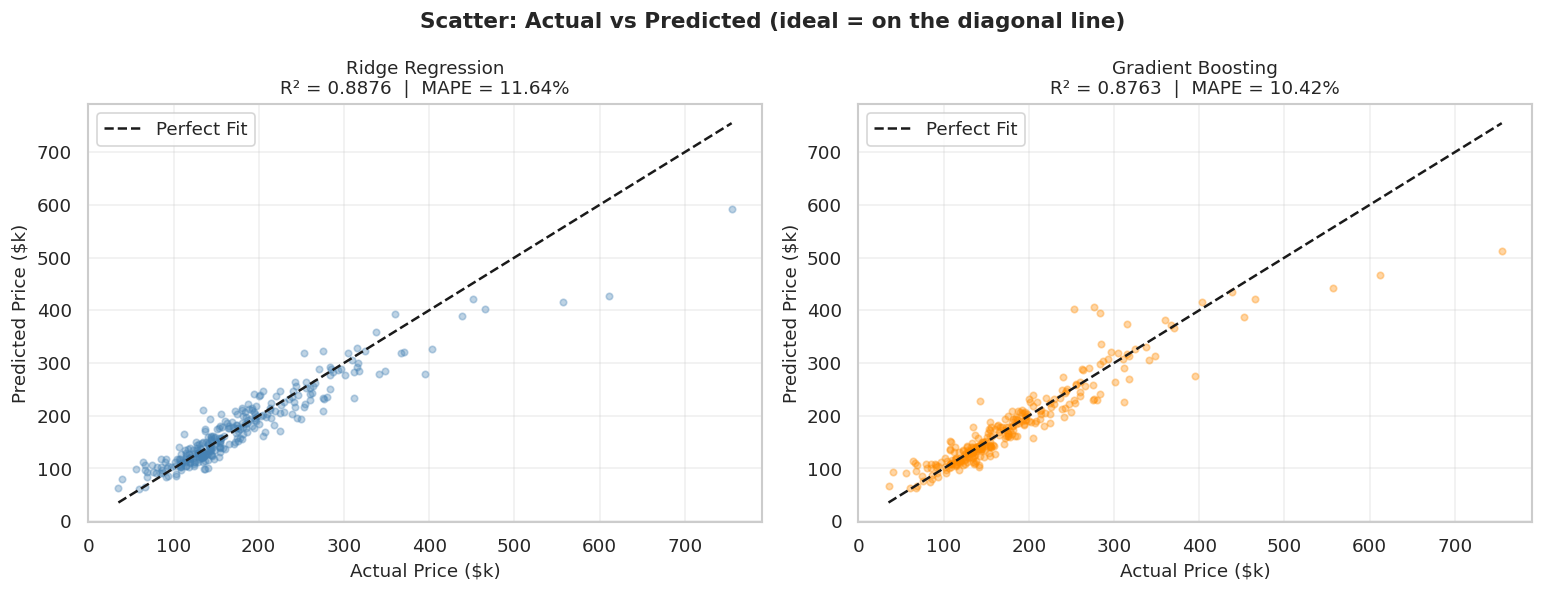

In [21]:
# Scatter Plot: Actual vs Predicted  (Points on the diagonal = perfect prediction)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Scatter: Actual vs Predicted (ideal = on the diagonal line)",
             fontsize=13, fontweight='bold')

for ax, preds, title, color, metrics in zip(
    axes,
    [ridge_preds, gb_preds],
    ['Ridge Regression', 'Gradient Boosting'],
    ['steelblue', 'darkorange'],
    [ridge_metrics, gb_metrics]
):
    ax.scatter(y_test_usd / 1e3, preds / 1e3,
               alpha=0.35, s=15, color=color)

    # Perfect prediction diagonal
    mn = min(y_test_usd.min(), preds.min()) / 1e3
    mx = max(y_test_usd.max(), preds.max()) / 1e3
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Fit')

    ax.set_xlabel("Actual Price ($k)", fontsize=11)
    ax.set_ylabel("Predicted Price ($k)", fontsize=11)
    ax.set_title(
        f"{title}\nR² = {metrics['R2']:.4f}  |  MAPE = {metrics['MAPE']:.2f}%",
        fontsize=11
    )
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

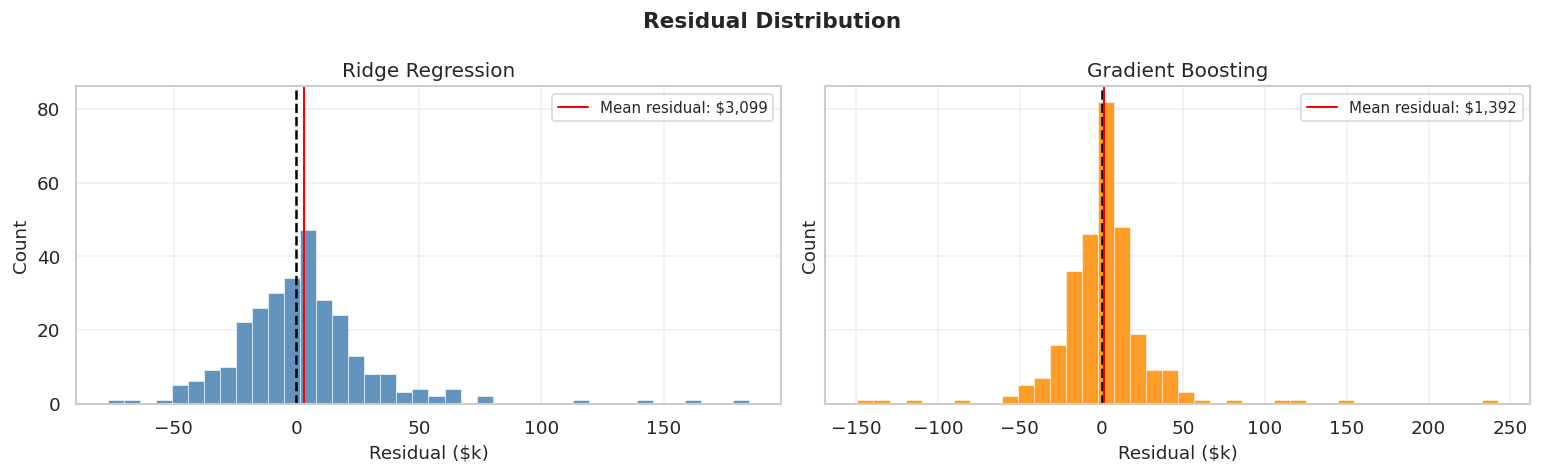

In [22]:
# Residual Distribution Plot  (Residuals = Actual - Predicted)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
fig.suptitle("Residual Distribution",
             fontsize=13, fontweight='bold')

for ax, preds, title, color in zip(
    axes,
    [ridge_preds, gb_preds],
    ['Ridge Regression', 'Gradient Boosting'],
    ['steelblue', 'darkorange']
):
    residuals = y_test_usd - preds
    ax.hist(residuals / 1e3, bins=40, color=color, edgecolor='white',
            linewidth=0.4, alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean() / 1e3, color='red', linestyle='-',
               linewidth=1.2, label=f'Mean residual: ${residuals.mean():,.0f}')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Residual ($k)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

well-calibrated model as it is bell shaped; residuals centered on 0, roughly normal

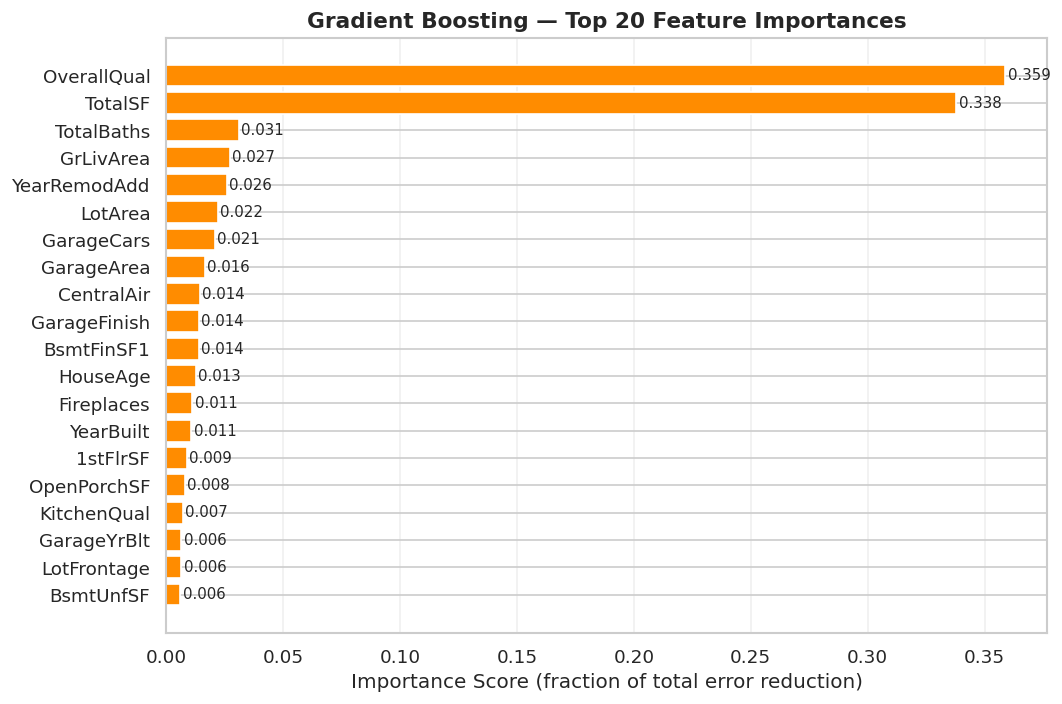

In [23]:
# Gradient Boosting tracks how much each feature reduced prediction error across all trees
gb_importances = pd.Series(gb.feature_importances_, index=selected_feats)
top20_imp = gb_importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top20_imp.index, top20_imp.values,
               color='darkorange', edgecolor='white')

for bar, val in zip(bars, top20_imp.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title("Gradient Boosting — Top 20 Feature Importances",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score (fraction of total error reduction)")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



Key insights:
• OverallQual and GrLivArea typically dominate — quality and size drive price"
• TotalSF (engineered feature) often ranks high → domain knowledge helps"
• Neighbourhood-related features capture location premium")

In [24]:
# final comparison summary
summary = pd.DataFrame({
    'Model'     : ['Ridge Regression', 'Gradient Boosting'],
    'MAE ($)'   : [f"${ridge_metrics['MAE']:,.0f}", f"${gb_metrics['MAE']:,.0f}"],
    'RMSE ($)'  : [f"${ridge_metrics['RMSE']:,.0f}", f"${gb_metrics['RMSE']:,.0f}"],
    'R²'        : [f"{ridge_metrics['R2']:.4f}", f"{gb_metrics['R2']:.4f}"],
    'MAPE (%)'  : [f"{ridge_metrics['MAPE']:.2f}%", f"{gb_metrics['MAPE']:.2f}%"],
    'Complexity': ['Low (interpretable)', 'High (ensemble)']
})

print("\n" + "═" * 60)
print("  FINAL MODEL COMPARISON")
print("═" * 60)
print(summary.to_string(index=False))
print("═" * 60)




════════════════════════════════════════════════════════════
  FINAL MODEL COMPARISON
════════════════════════════════════════════════════════════
            Model MAE ($) RMSE ($)     R² MAPE (%)          Complexity
 Ridge Regression $19,419  $29,360 0.8876   11.64% Low (interpretable)
Gradient Boosting $17,610  $30,804 0.8763   10.42%     High (ensemble)
════════════════════════════════════════════════════════════


In [25]:
print("\n Gradient Boosting typically wins on accuracy.")
print("   Ridge Regression wins on interpretability & speed.")


 Gradient Boosting typically wins on accuracy.
   Ridge Regression wins on interpretability & speed.
